# J4-AM — Tokenisation & Word Embeddings

**Objectif** : trois parties pratiques progressives.

| Partie | Contenu |
|--------|---------|
| 1 | Explorer GloVe (voisins, analogies, t-SNE) |
| 2 | Pipeline GloVe → PCA → LogisticRegression sur SST-2 |
| 3 | `nn.Embedding` entraînable (random vs GloVe frozen vs fine-tuned) |

In [1]:
# Colab : décommenter si nécessaire
!pip install -q gensim datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import gensim.downloader as api
from datasets import load_dataset
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


In [3]:
# ~160 Mo — téléchargé une fois puis mis en cache par gensim
print("Chargement de GloVe (glove-wiki-gigaword-100)...")
glove = api.load("glove-wiki-gigaword-100")
print(f"Vocabulaire : {len(glove):,} mots | Dimension : {glove.vector_size}")

Chargement de GloVe (glove-wiki-gigaword-100)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulaire : 400,000 mots | Dimension : 100


---
## Partie 1 — Explorer GloVe

On dispose de vecteurs pré-entraînés sur Wikipedia + Gigaword (6 milliards de tokens).
On va vérifier expérimentalement les propriétés vues en cours.

In [4]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Similarité cosinus entre deux vecteurs."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def nearest_neighbors(word: str, k: int = 5) -> list:
    """k plus proches voisins d'un mot dans l'espace GloVe."""
    return glove.most_similar(word, topn=k)


for word in ["cat", "king", "paris"]:
    neighbors = nearest_neighbors(word)
    print(f"\nVoisins de '{word}' :")
    for w, score in neighbors:
        print(f"  {w:20s}  cos={score:.3f}")


Voisins de 'cat' :
  dog                   cos=0.880
  rabbit                cos=0.742
  cats                  cos=0.732
  monkey                cos=0.729
  pet                   cos=0.719

Voisins de 'king' :
  prince                cos=0.768
  queen                 cos=0.751
  son                   cos=0.702
  brother               cos=0.699
  monarch               cos=0.698

Voisins de 'paris' :
  prohertrib            cos=0.799
  france                cos=0.748
  london                cos=0.734
  brussels              cos=0.704
  french                cos=0.693


In [5]:
def analogy(positive: list, negative: list, k: int = 3) -> list:
    """Résout une analogie vectorielle : positive - negative = ?"""
    return glove.most_similar(positive=positive, negative=negative, topn=k)


print("Analogies vectorielles")
print("-" * 50)

experiments = [
    (["king",   "woman"], ["man"],    "king - man + woman"),
    (["paris",  "italy"], ["france"], "paris - france + italy"),
    (["bigger", "small"], ["big"],    "bigger - big + small"),
    (["walking", "swim"], ["walk"],   "walking - walk + swim"),
]

for positive, negative, label in experiments:
    result = analogy(positive, negative)
    top = result[0]
    print(f"  {label:35s}  →  {top[0]:15s} (score={top[1]:.3f})")

Analogies vectorielles
--------------------------------------------------
  king - man + woman                   →  queen           (score=0.770)
  paris - france + italy               →  rome            (score=0.819)
  bigger - big + small                 →  larger          (score=0.892)
  walking - walk + swim                →  swimming        (score=0.801)


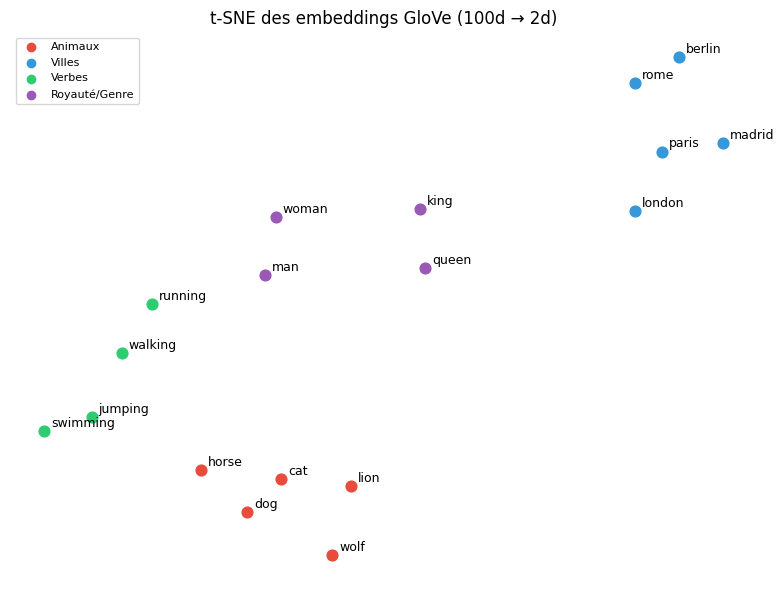

In [6]:
words = [
    "cat", "dog", "wolf", "lion", "horse",          # animaux
    "paris", "london", "berlin", "rome", "madrid",  # villes
    "running", "jumping", "walking", "swimming",    # verbes
    "king", "queen", "man", "woman",                # royauté / genre
]

vectors = np.array([glove[w] for w in words])

# 18 mots seulement : t-SNE directement sur les 100d GloVe
coords = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(vectors)

colors = ["#e74c3c"] * 5 + ["#3498db"] * 5 + ["#2ecc71"] * 4 + ["#9b59b6"] * 4
labels_legend = ["Animaux"] * 5 + ["Villes"] * 5 + ["Verbes"] * 4 + ["Royauté/Genre"] * 4

fig, ax = plt.subplots(figsize=(8, 6))
for (x, y), word, color in zip(coords, words, colors):
    ax.scatter(x, y, color=color, s=60)
    ax.annotate(word, (x, y), fontsize=9,
                textcoords="offset points", xytext=(5, 3))

# Légende manuelle
for color, label in [("#e74c3c", "Animaux"), ("#3498db", "Villes"),
                     ("#2ecc71", "Verbes"), ("#9b59b6", "Royauté/Genre")]:
    ax.scatter([], [], color=color, label=label)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("t-SNE des embeddings GloVe (100d → 2d)")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Partie 2 — Pipeline texte → classifieur simple

Tâche : **analyse de sentiment** sur SST-2 (Stanford Sentiment Treebank, binaire).

Pipeline : phrase → moyenne des embeddings GloVe → PCA → `LogisticRegression`

In [7]:
dataset = load_dataset("glue", "sst2")

X_train_raw = dataset["train"]["sentence"]
y_train     = dataset["train"]["label"]
X_val_raw   = dataset["validation"]["sentence"]
y_val       = dataset["validation"]["label"]

print(f"Train      : {len(X_train_raw):,} exemples")
print(f"Validation : {len(X_val_raw):,} exemples")
print(f"Exemple    : '{X_train_raw[0]}'  →  {y_train[0]}")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train      : 67,349 exemples
Validation : 872 exemples
Exemple    : 'hide new secretions from the parental units '  →  0


In [8]:
GLOVE_DIM = glove.vector_size  # 100


def encode_sentence(sentence: str) -> np.ndarray:
    """Phrase (str)  →  vecteur moyen des tokens GloVe connus [GLOVE_DIM]."""
    tokens = sentence.lower().split()
    vecs = [glove[t] for t in tokens if t in glove]
    return np.mean(vecs, axis=0) if vecs else np.zeros(GLOVE_DIM)


print("Encodage des phrases...")
X_train_glove = np.array([encode_sentence(s) for s in X_train_raw])
X_val_glove   = np.array([encode_sentence(s) for s in X_val_raw])
print(f"Shape train : {X_train_glove.shape}")

Encodage des phrases...
Shape train : (67349, 100)


In [ ]:
results = {}


def run_logreg(X_tr, X_va, name: str) -> float:
    """X_tr, X_va arrays  →  float : accuracy sur validation."""
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(X_tr, y_train)
    acc = accuracy_score(y_val, clf.predict(X_va))
    print(f"  {name:30s}  acc={acc:.4f}")
    return acc

In [ ]:
print("--- Expériences LogisticRegression ---")

# Baseline aléatoire
np.random.seed(42)
results["Random 100d"] = run_logreg(
    np.random.randn(*X_train_glove.shape),
    np.random.randn(*X_val_glove.shape),
    "Random 100d",
)

# GloVe brut (100d)
results["GloVe 100d"] = run_logreg(X_train_glove, X_val_glove, "GloVe 100d")

# GloVe + PCA
for n in [50, 20, 10]:
    pca = PCA(n_components=n)
    name = f"GloVe + PCA {n:2d}d"
    results[name] = run_logreg(pca.fit_transform(X_train_glove), pca.transform(X_val_glove), name)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(results.keys()), list(results.values()), color="steelblue")
ax.set_xlabel("Accuracy (validation)")
ax.set_xlim(0.5, 1.0)
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="Chance")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Partie 3 — `nn.Embedding` entraînable

Même tâche SST-2, mais avec un réseau PyTorch :

```
nn.Embedding  →  mean pooling  →  nn.Linear(emb_dim, 2)
```

On compare trois initialisations :
- **Random** : embeddings aléatoires, appris de zéro
- **GloVe frozen** : embeddings GloVe, non modifiés
- **GloVe fine-tuned** : embeddings GloVe, continuent d'être mis à jour

In [10]:
MAX_LEN = 50
PAD_IDX = 0
UNK_IDX = 1


def build_vocab(sentences: list, min_freq: int = 2) -> dict:
    """Phrases d'entraînement  →  dict mot→indice (freq >= min_freq)."""
    counter = Counter(tok for s in sentences for tok in s.lower().split())
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode_tokens(sentence: str, vocab: dict) -> list:
    """Phrase  →  liste d'indices paddée/tronquée à MAX_LEN."""
    tokens = [vocab.get(t, UNK_IDX) for t in sentence.lower().split()[:MAX_LEN]]
    return tokens + [PAD_IDX] * (MAX_LEN - len(tokens))


vocab = build_vocab(X_train_raw)
print(f"Taille vocabulaire : {len(vocab):,}")

Taille vocabulaire : 14,311


In [ ]:
class SSTDataset(Dataset):
    """Dataset SST-2 encodé en indices de tokens."""

    def __init__(self, sentences: list, labels: list, vocab: dict) -> None:
        """Entrée : phrases brutes + labels + vocabulaire  |  Sortie : tenseurs (indices, label)."""
        self.X = torch.tensor(
            [encode_tokens(s, vocab) for s in sentences], dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

In [ ]:
class SentimentMLP(nn.Module):
    """nn.Embedding + mean pooling + Linear → 2 classes (sentiment binaire)."""

    def __init__(self, vocab_size: int, emb_dim: int = 100) -> None:
        """Entrée : indices [B, T]  |  Sortie : logits [B, 2]."""
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.fc = nn.Linear(emb_dim, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x [B, T]  →  logits [B, 2]."""
        emb = self.embedding(x)    # [B, T, emb_dim]
        pooled = emb.mean(dim=1)   # [B, emb_dim]
        return self.fc(pooled)     # [B, 2]

In [12]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
) -> float:
    """model + loader (une époque)  →  float : loss cross-entropy moyenne."""
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    """model + loader  →  float : accuracy ∈ [0, 1]."""
    model.eval()
    correct = 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        correct += (model(X).argmax(1) == y).sum().item()
    return correct / len(loader.dataset)

In [13]:
train_ds = SSTDataset(X_train_raw, y_train, vocab)
val_ds   = SSTDataset(X_val_raw,   y_val,   vocab)

loader_tr = DataLoader(train_ds, batch_size=64, shuffle=True)
loader_va = DataLoader(val_ds,   batch_size=256)

print(f"Batches train : {len(loader_tr)} | val : {len(loader_va)}")

Batches train : 1053 | val : 4


In [14]:
def build_glove_matrix(vocab: dict, glove, dim: int = 100) -> torch.Tensor:
    """vocab + glove  →  matrice W_e [V, dim] initialisée avec les vecteurs GloVe."""
    W = torch.zeros(len(vocab), dim)
    nn.init.normal_(W, std=0.01)  # valeur par défaut pour les mots hors GloVe
    for word, idx in vocab.items():
        if word in glove:
            W[idx] = torch.tensor(glove[word], dtype=torch.float32)
    return W


W_glove = build_glove_matrix(vocab, glove)
print(f"Matrice GloVe : {W_glove.shape}")

Matrice GloVe : torch.Size([14311, 100])


### 1. Embeddings aléatoires — baseline

In [ ]:
EPOCHS = 10
emb_results = {}


def run_experiment(name: str, model: nn.Module) -> float:
    """name + model  →  float : accuracy validation après EPOCHS époques."""
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    print(f"\n--- {name} ---")
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, loader_tr, optimizer, criterion)
        acc  = evaluate(model, loader_va)
        print(f"  Époque {epoch}/{EPOCHS}  loss={loss:.4f}  acc={acc:.4f}")
    return acc


model_rand = SentimentMLP(len(vocab))
emb_results["Random init"] = run_experiment("Random init", model_rand)

### 2. GloVe frozen — embeddings figés

In [ ]:
model_frozen = SentimentMLP(len(vocab))
model_frozen.embedding = nn.Embedding.from_pretrained(
    W_glove, freeze=True, padding_idx=PAD_IDX
)
emb_results["GloVe frozen"] = run_experiment("GloVe frozen", model_frozen)

### 3. GloVe fine-tuned — embeddings ajustés

In [ ]:
model_ft = SentimentMLP(len(vocab))
model_ft.embedding = nn.Embedding.from_pretrained(
    W_glove.clone(), freeze=False, padding_idx=PAD_IDX
)
emb_results["GloVe fine-tuned"] = run_experiment("GloVe fine-tuned", model_ft)

### Résumé

In [ ]:
print("\n" + "=" * 40)
print("Résumé final (accuracy validation)")
print("=" * 40)
for name, acc in emb_results.items():
    print(f"  {name:22s} : {acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(list(emb_results.keys()), list(emb_results.values()), color=["#e74c3c", "#3498db", "#2ecc71"])
ax.set_ylabel("Accuracy (validation)")
ax.set_ylim(0.5, 1.0)
ax.set_title("Comparaison des initialisations d'embeddings (SST-2)")
plt.tight_layout()
plt.show()